<a href="https://colab.research.google.com/github/PrasadJagdale1939/Google_Colab_Practice/blob/main/CaseStudy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns
import scipy
from scipy import stats
from scipy.stats import binom, poisson, norm, t
from numpy.linalg import inv
import statsmodels
from statsmodels import stats
from statsmodels.stats import weightstats as ssw
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [ ]:
df = pd.read_csv('/content/ElectroMart.xlsx.csv')

In [ ]:
df.head()

,WeekStart,WeekNumber,Month,Quarter,Store,Region,StoreType,Employees,Sales_Lakh,Orders,AvgDeliveryDays,Satisfaction,OnlineSales_Lakh,OfflineSales_Lakh,Returns,MarketingSpend_Lakh,PerformanceBand
0,2025-01-06,1,Jan,Q1,S01,North,Medium,22,87.9,630,3.1,4.40,38.4,49.5,26,5.3,Medium
1,2025-01-06,1,Jan,Q1,S02,North,Medium,20,83.7,590,3.1,4.24,36.1,47.6,25,4.3,Medium
2,2025-01-06,1,Jan,Q1,S03,North,Small,18,72.2,510,2.8,4.39,30.3,41.9,17,4.7,Medium
3,2025-01-06,1,Jan,Q1,S04,North,Large,24,83.7,616,2.7,4.35,37.3,46.4,20,4.8,Medium
4,2025-01-06,1,Jan,Q1,S05,North,Medium,21,77.6,560,2.9,4.49,34.3,43.3,20,4.7,Medium


In [ ]:
df.describe()

,WeekNumber,Employees,Sales_Lakh,Orders,AvgDeliveryDays,Satisfaction,OnlineSales_Lakh,OfflineSales_Lakh,Returns,MarketingSpend_Lakh
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,20.500000,20.800000,89.944333,640.259167,2.875083,4.364567,44.412750,45.531583,25.577500,4.955833
std,11.548209,2.496369,13.227339,92.127647,0.629909,0.213442,11.861965,3.984211,3.333655,0.527650
min,1.000000,16.000000,53.400000,397.000000,1.600000,3.760000,18.300000,32.900000,13.000000,3.300000
25%,10.750000,19.000000,81.300000,578.000000,2.400000,4.230000,35.600000,42.975000,23.000000,4.600000
50%,20.500000,21.000000,90.650000,646.000000,2.800000,4.370000,43.600000,45.400000,26.000000,5.000000
75%,30.250000,23.000000,99.200000,706.250000,3.200000,4.510000,52.700000,48.200000,28.000000,5.300000
max,40.000000,26.000000,122.500000,862.000000,4.800000,4.940000,76.200000,58.300000,36.000000,6.600000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   WeekStart            1200 non-null   object 
 1   WeekNumber           1200 non-null   int64  
 2   Month                1200 non-null   object 
 3   Quarter              1200 non-null   object 
 4   Store                1200 non-null   object 
 5   Region               1200 non-null   object 
 6   StoreType            1200 non-null   object 
 7   Employees            1200 non-null   int64  
 8   Sales_Lakh           1200 non-null   float64
 9   Orders               1200 non-null   int64  
 10  AvgDeliveryDays      1200 non-null   float64
 11  Satisfaction         1200 non-null   float64
 12  OnlineSales_Lakh     1200 non-null   float64
 13  OfflineSales_Lakh    1200 non-null   float64
 14  Returns              1200 non-null   int64  
 15  MarketingSpend_Lakh  1200 non-null   f

1.Management wants to know:

Which stores have the highest and lowest average sales over the entire period?

Create an appropriate visualization and identify the top three and bottom three stores

Text(0.5, 0, 'Average Weekly Sales (Lakh)')

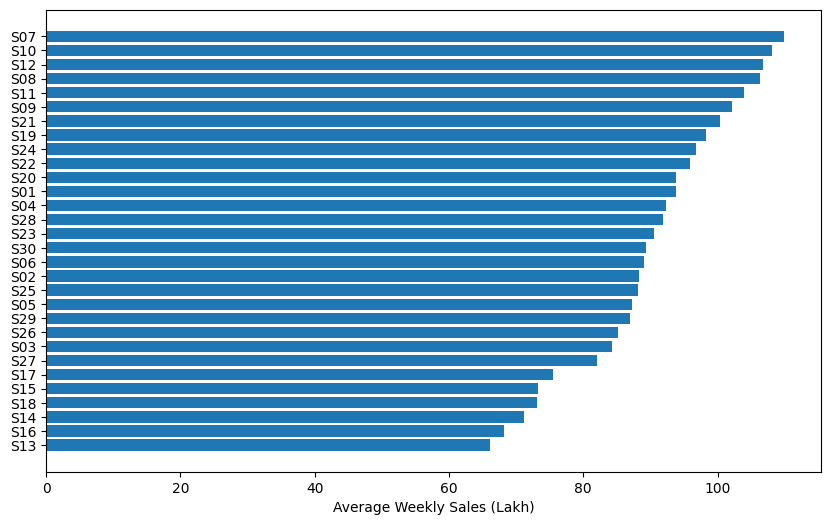

In [ ]:
store_avg = df.groupby('Store')['Sales_Lakh'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10,6))
ax.barh(store_avg.index[::-1], store_avg.values[::-1])
ax.set_xlabel('Average Weekly Sales (Lakh)')

2.The regional managers want to understand the relationship between average delivery time and customer satisfaction.

Does the data show a clear relationship between delivery time and satisfaction?

Create an appropriate visualization and state whether the relationship is positive, negative, or weak/no clear relationship.

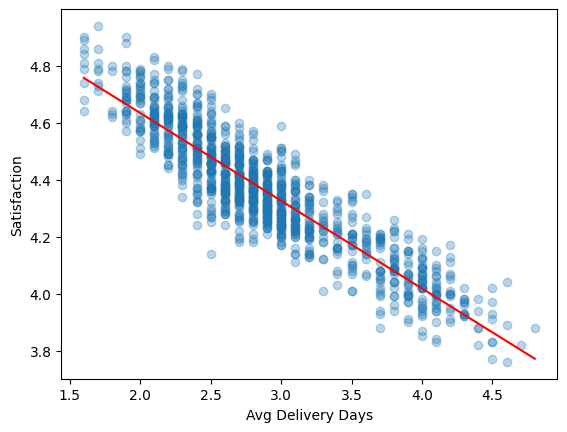

-0.9095555839197993


In [ ]:
fig, ax = plt.subplots()
ax.scatter(df['AvgDeliveryDays'], df['Satisfaction'], alpha=0.3)

corr = df['AvgDeliveryDays'].corr(df['Satisfaction'])
z = np.polyfit(df['AvgDeliveryDays'], df['Satisfaction'], 1)

xs = np.linspace(df['AvgDeliveryDays'].min(), df['AvgDeliveryDays'].max(), 100)
ax.plot(xs, np.polyval(z, xs), color='red')

ax.set_xlabel('Avg Delivery Days')
ax.set_ylabel('Satisfaction')
plt.show()

print(corr)

3.The marketing department wants to understand how ElectroMart's sales are divided between its online and offline channels.

How does the sales-channel mix differ across the five regions?
Create an appropriate visualization and identify the region with the highest and lowest online contribution.


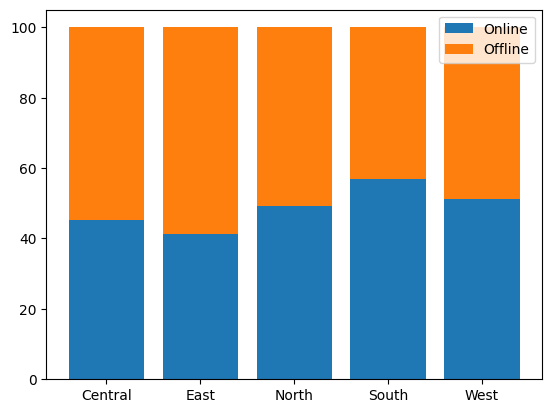

In [ ]:
region_channel = df.groupby('Region')[['OnlineSales_Lakh','OfflineSales_Lakh']].sum()
region_pct = region_channel.div(region_channel.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots()
ax.bar(region_pct.index, region_pct['OnlineSales_Lakh'], label='Online')
ax.bar(region_pct.index, region_pct['OfflineSales_Lakh'],
       bottom=region_pct['OnlineSales_Lakh'], label='Offline')
ax.legend()
plt.show()

4.The operations manager suspects that some stores have unusually long delivery times.

What does the distribution of delivery times tell you about the company's overall delivery performance, and are there unusually slow observations that deserve attention?

Create an appropriate visualization and draw a conclusion about the distribution.

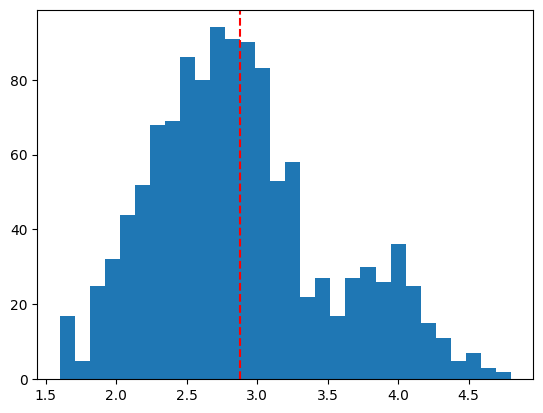

In [ ]:
fig, ax = plt.subplots()
ax.hist(df['AvgDeliveryDays'], bins=30)
ax.axvline(df['AvgDeliveryDays'].mean(), color='red', linestyle='--')

5.The CEO wants to know whether the company's sales performance is improving over time.

How has overall weekly sales changed during the 40-week period?
Create an appropriate visualization and conclude whether the overall sales trend is increasing, decreasing, or broadly flat.


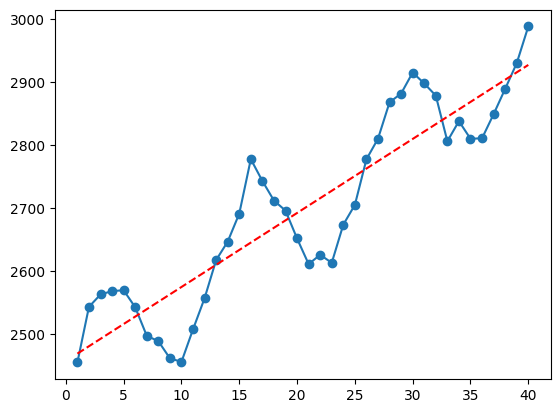

In [ ]:
weekly = df.groupby('WeekNumber')['Sales_Lakh'].sum()
fig, ax = plt.subplots()
ax.plot(weekly.index, weekly.values, marker='o')
z = np.polyfit(weekly.index, weekly.values, 1)
ax.plot(weekly.index, np.polyval(z, weekly.index), '--', color='red')